 <h1 align="center"><fontsize="5">Graph Networks</font></h1>

<h1 align="center"><font size="5"> OBG Dataset - EDA for Graph Node Prediction</font ></h1 >

<div class="alert alert-info"><p>
This is the third of a series of notebooks for data exploration of datasets for node and graph classification and link prediction. The dataset explored here is the OGB-arxiv citations network  for Node Property Prediction.
</p></div>

### Table of Contents


---

1. [Introduction](#introduction)
2. [Setup and Imports](#setup-and-imports)
3. [Load Dataset](#load-dataset)
4. [Graph-Level Statistics](#graph-level-statistics)
5. [Graph Visualization](#graph-visualization)
6. [Node Distribution](#node-distribution)
7. [Train, Validation, Test Splits node distribution](#train-validation-test-splits)
8. [References](#references)


<a id="introduction"></a>

## 1. Introduction

### OGBN-Arxiv Dataset

[`ogbn-arxiv`](https://ogb.stanford.edu/docs/nodeprop/#ogbn-arxiv) is a **directed citation network** of Computer Science papers indexed by the Microsoft Academic Graph (MAG).

* **Nodes:** 169,343 arXiv papers
* **Edges:** 1,166,243 directed citation links
* **Node features:** 128-dimensional vectors derived from averaged word embeddings of each paper's title and abstract
* **Target:** Primary arXiv subject category
* **Classes:** 40
* **Task:** Multi-class node classification
* **Evaluation metric:** Accuracy

Each node represents a paper, while a directed edge indicates that one paper cites another.

### Temporal Split

Rather than using a random split, `ogbn-arxiv` uses publication year to create a realistic prediction scenario:

| Split          | Papers                      |
| -------------- | --------------------------- |
| **Training**   | Published up to 2017        |
| **Validation** | Published in 2018           |
| **Test**       | Published from 2019 onwards |

The goal is, therefore, to train on historical papers and predict the subject categories of newer publications.


<a id="setup-and-imports"></a>

## 2. Setup and Imports

In [1]:
# Stdlib
from collections import Counter

# Plotting
import altair as alt

# Global altair config — must run once before any chart is displayed
alt.data_transformers.enable("vegafusion")
alt.renderers.enable("svg")

################################
# If running this notebook on JupyterLab, Jupyter Notebook, VSCode-Python, or Colab,
# uncomment alt.renderers.enable("jupyter"). For interactive plots uncomment
# alt.renderers.enable("html").
###############################

# alt.renderers.enable("jupyter")
# alt.renderers.enable("html")


RendererRegistry.enable('svg')

<a id="load-dataset"></a>

## 3. Load Dataset

In [2]:
# Import the necessary functions to access the dataset and root path
from src.common.datasets import load_ogb_node
from src.common.paths import get_project_root

In [3]:
root = get_project_root()
data_path = root / "data"

In [4]:
# Load the dataset
dataset, graph, _ = load_ogb_node(name="ogbn-arxiv", root=data_path)

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:37<00:00,  2.16it/s]
Processing...


Extracting /Users/az-asc/PycharmProjects/GraphNetworks/data/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 38479.85it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 8256.50it/s]

Saving...



Done!


In [5]:
print(graph)

Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343], train_mask=[169343], val_mask=[169343], test_mask=[169343])


<a id="graph-level-statistics"></a>

## 4. Graph-Level Statistics

This section will compute some statistics about the graph. Some traditional metrics include: density, numer of nodes, number of edges, self-nodes, average node degree, number of connected components, number of classes, etc. Here we wil also compute the homiphily and assortativity metrics and the degree spread. The homophily and assortativity metrics are computed using the torch_geometric.utils library, and the degree spread is computed using the scipy.sparse.csgraph library. There are three types of homophily metrics in the torch library. Below we provide the definition of homophily and the assortativity [2].

Homophily:

Edge homophily ratio is the fraction of edges in a graph which connects nodes that have the same class label
Node homophily ration is the edge homophily normalized across neighbourhoods
Insensitive edge homophily ratio edge homophily is modified to be insensitive to the number of classes and size of each class
Assortativity coefficient in a network refers to the tendency of nodes to connect with other similar nodes over dissimilar nodes.
https://pytorch-geometric.readthedocs.io/en/latest/modules/utils.html?highlight=homophily#torch_geometric.utils.homophily

The table below shows the 40 subjects of the papers in the dataset, mapped to their corresponding IDs and class.


| ID | Class   | Subject                                         |
| -: | ------- | ----------------------------------------------- |
|  0 | `cs.NA` | Numerical Analysis                              |
|  1 | `cs.MM` | Multimedia                                      |
|  2 | `cs.LO` | Logic in Computer Science                       |
|  3 | `cs.CY` | Computers and Society                           |
|  4 | `cs.CR` | Cryptography and Security                       |
|  5 | `cs.DC` | Distributed, Parallel, and Cluster Computing    |
|  6 | `cs.HC` | Human-Computer Interaction                      |
|  7 | `cs.CE` | Computational Engineering, Finance, and Science |
|  8 | `cs.NI` | Networking and Internet Architecture            |
|  9 | `cs.CC` | Computational Complexity                        |
| 10 | `cs.AI` | Artificial Intelligence                         |
| 11 | `cs.MA` | Multiagent Systems                              |
| 12 | `cs.GL` | General Literature                              |
| 13 | `cs.NE` | Neural and Evolutionary Computing               |
| 14 | `cs.SC` | Symbolic Computation                            |
| 15 | `cs.AR` | Hardware Architecture                           |
| 16 | `cs.CV` | Computer Vision and Pattern Recognition         |
| 17 | `cs.GR` | Graphics                                        |
| 18 | `cs.ET` | Emerging Technologies                           |
| 19 | `cs.SY` | Systems and Control                             |
| 20 | `cs.CG` | Computational Geometry                          |
| 21 | `cs.OH` | Other Computer Science                          |
| 22 | `cs.PL` | Programming Languages                           |
| 23 | `cs.SE` | Software Engineering                            |
| 24 | `cs.LG` | Machine Learning                                |
| 25 | `cs.SD` | Sound                                           |
| 26 | `cs.SI` | Social and Information Networks                 |
| 27 | `cs.RO` | Robotics                                        |
| 28 | `cs.IT` | Information Theory                              |
| 29 | `cs.PF` | Performance                                     |
| 30 | `cs.CL` | Computation and Language                        |
| 31 | `cs.IR` | Information Retrieval                           |
| 32 | `cs.MS` | Mathematical Software                           |
| 33 | `cs.FL` | Formal Languages and Automata Theory            |
| 34 | `cs.DS` | Data Structures and Algorithms                  |
| 35 | `cs.OS` | Operating Systems                               |
| 36 | `cs.GT` | Computer Science and Game Theory                |
| 37 | `cs.DB` | Databases                                       |
| 38 | `cs.DL` | Digital Libraries                               |
| 39 | `cs.DM` | Discrete Mathematics                            |

In [6]:
print(f'Num of classes: {dataset.num_classes}')

Num of classes: 40


In [7]:
# Import necessary libraries and fuction to compute graph statistics
import pandas as pd
from src.common.graph_eda import GraphEDA

In [8]:
path_to_labels = 'ogbn_arxiv/mapping/labelidx2arxivcategeory.csv.gz'
path_to_node = 'ogbn_arxiv/mapping/nodeidx2paperid.csv.gz'

In [9]:
# Access labels and node to paper mapping
labels = pd.read_csv(data_path / path_to_labels)
node_to_paper = pd.read_csv(data_path / path_to_node)

In [10]:
print(labels.head())

   label idx arxiv category
0          0    arxiv cs na
1          1    arxiv cs mm
2          2    arxiv cs lo
3          3    arxiv cs cy
4          4    arxiv cs cr


In [11]:
print(node_to_paper.head())

   node idx   paper id
0         0    9657784
1         1   39886162
2         2  116214155
3         3  121432379
4         4  231147053


In [12]:
# Convert label to dictionary
label_map = labels.set_index("label idx")["arxiv category"].to_dict()

The official OGB GCN/GraphSAGE baseline symmetrizes ogbn-arxiv after converting the graph to a sparse adjacency representation. This implementation will keep PyG's standard `edge_index` representation. During preprocessing, `to_undirected()` will be used as the `edge_index` equivalent of `data.adj_t.to_symmetric()` so that message passing can occur in both directions.

To validate this preprocessing step, graph summary statistics will be calculated before and after applying `to_undirected()`. This will help confirm that the overall graph structure is preserved while showing the expected changes, such as the increase in edge count and the graph becoming undirected.


In [13]:
stats = GraphEDA(graph, label_map)
print("=== BEFORE to_undirected() ===")
stats.summary()

=== BEFORE to_undirected() ===
=== Graph structure ===
Number of nodes: 169343
Number of edges: 1166243
Number of node features: 128
Number of classes: 40
Graph density: 0.000041

=== Degree ===
Average node degree: 6.89
Degree min / max / std: 0 / 436 / 8.88

=== Class balance ===
arxiv cs na: 565 (0.33%)
arxiv cs mm: 687 (0.41%)
arxiv cs lo: 4839 (2.86%)
arxiv cs cy: 2080 (1.23%)
arxiv cs cr: 5862 (3.46%)
arxiv cs dc: 4958 (2.93%)
arxiv cs hc: 1618 (0.96%)
arxiv cs ce: 589 (0.35%)
arxiv cs ni: 6232 (3.68%)
arxiv cs cc: 2820 (1.67%)
arxiv cs ai: 7869 (4.65%)
arxiv cs ma: 750 (0.44%)
arxiv cs gl: 29 (0.02%)
arxiv cs ne: 2358 (1.39%)
arxiv cs sc: 597 (0.35%)
arxiv cs ar: 403 (0.24%)
arxiv cs cv: 27321 (16.13%)
arxiv cs gr: 515 (0.30%)
arxiv cs et: 749 (0.44%)
arxiv cs sy: 2877 (1.70%)
arxiv cs cg: 2076 (1.23%)
arxiv cs oh: 393 (0.23%)
arxiv cs pl: 1903 (1.12%)
arxiv cs se: 2834 (1.67%)
arxiv cs lg: 22187 (13.10%)
arxiv cs sd: 1257 (0.74%)
arxiv cs si: 4605 (2.72%)
arxiv cs ro: 4801 (2.8

In [14]:
from torch_geometric.utils import to_undirected
graph.edge_index = to_undirected(graph.edge_index)

In [15]:
print("n=== AFTER to_undirected() ===")
stats = GraphEDA(graph, label_map)
stats.summary()

n=== AFTER to_undirected() ===
=== Graph structure ===
Number of nodes: 169343
Number of edges: 2315598
Number of node features: 128
Number of classes: 40
Graph density: 0.000081

=== Degree ===
Average node degree: 13.67
Degree min / max / std: 1 / 13161 / 68.64

=== Class balance ===
arxiv cs na: 565 (0.33%)
arxiv cs mm: 687 (0.41%)
arxiv cs lo: 4839 (2.86%)
arxiv cs cy: 2080 (1.23%)
arxiv cs cr: 5862 (3.46%)
arxiv cs dc: 4958 (2.93%)
arxiv cs hc: 1618 (0.96%)
arxiv cs ce: 589 (0.35%)
arxiv cs ni: 6232 (3.68%)
arxiv cs cc: 2820 (1.67%)
arxiv cs ai: 7869 (4.65%)
arxiv cs ma: 750 (0.44%)
arxiv cs gl: 29 (0.02%)
arxiv cs ne: 2358 (1.39%)
arxiv cs sc: 597 (0.35%)
arxiv cs ar: 403 (0.24%)
arxiv cs cv: 27321 (16.13%)
arxiv cs gr: 515 (0.30%)
arxiv cs et: 749 (0.44%)
arxiv cs sy: 2877 (1.70%)
arxiv cs cg: 2076 (1.23%)
arxiv cs oh: 393 (0.23%)
arxiv cs pl: 1903 (1.12%)
arxiv cs se: 2834 (1.67%)
arxiv cs lg: 22187 (13.10%)
arxiv cs sd: 1257 (0.74%)
arxiv cs si: 4605 (2.72%)
arxiv cs ro: 4801 

<a id="graph-visualization"></a>

## 5. Graph Visualization

In this section we would visualize the graph node distribution with different for a sample of nodes. We would use the spring and atlas 2 algorithm to render the visualization.

In [18]:
from src.common.altair_plots import convert_to_networkx, plot_label_distribution, compute_layout, plot_graph, GraphPlotParams

In [19]:
arxiv_path = "outputs/figures/arxiv"
figs_dir = root / arxiv_path

In [20]:
# Convert graph to networkx
samples = 1500
G = convert_to_networkx(graph, n_sample=samples, label_dict=label_map)
# Compute the graph layout
pos = compute_layout(G, graph_type='forceatlas2')

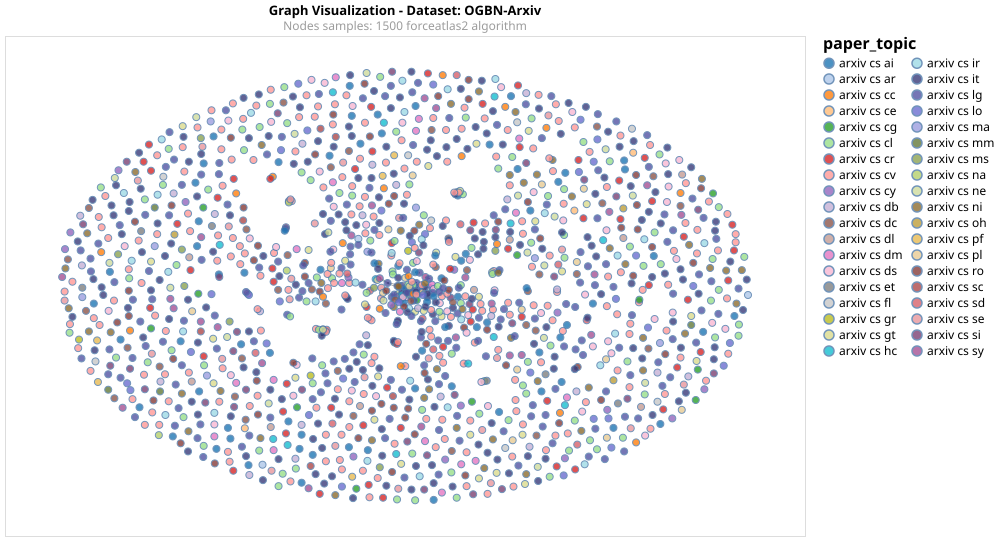

In [21]:
# Plot the graph applying forceatlas2 layout
plot_graph(G, pos, node_tooltip=["paper_topic"], node_size=50, edge_width=0.8,
           nodes=samples, sampling_type="forceatlas2", dataset_name="OGBN-Arxiv",
           alpha=0.8, curved_edges=True, path_to_plots=figs_dir,
           plot_name='ogbnarx_graph_atlas2', cmap="tableau10")

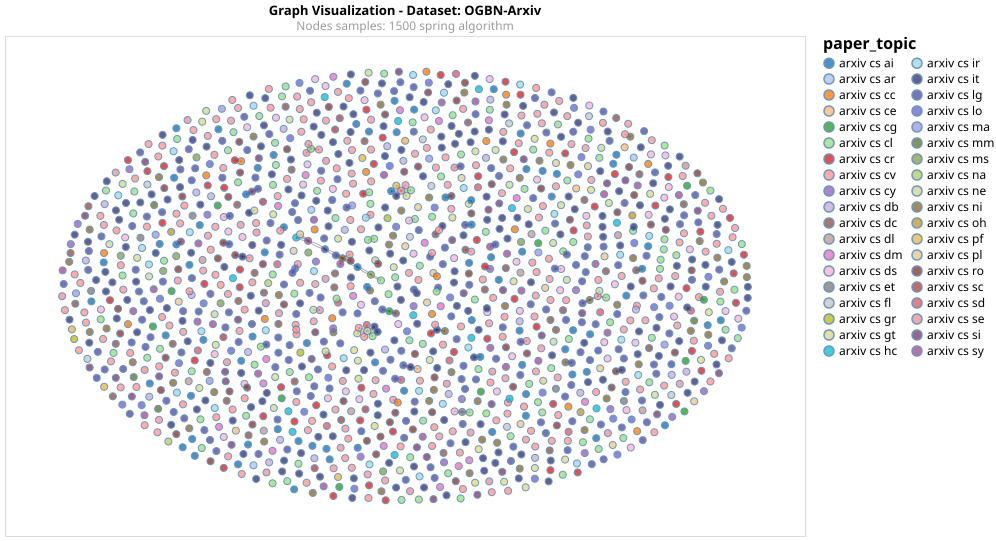

In [22]:
# Plot the graph applying spring layout
pos = compute_layout(G, graph_type='spring')
plot_graph(G, pos, node_tooltip=["paper_topic"], node_size=50, edge_width=0.8,
           nodes=samples, sampling_type="spring", dataset_name="OGBN-Arxiv",
           alpha=0.8, curved_edges=True, path_to_plots=figs_dir,
           plot_name='ogbnarx_graph_spring', cmap="tableau10")

<a id="node-distribution"></a>
## 6. Node Distribution

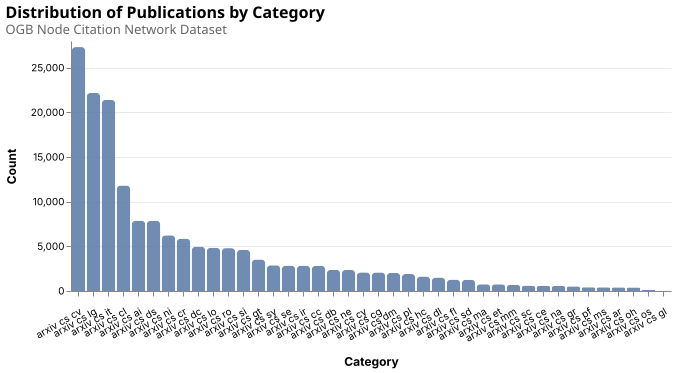

In [23]:
# Visualize the distribution of the node labels in the graph
plot_label_distribution(graph.y, path_to_graph=figs_dir, graph_name='data_dist',
                        label_dict=label_map, title="Distribution of Publications by Category",
                        subtitle="OGB Node Citation Network Dataset", split="", width= 600, height= 250)

<a id="train-validation-test-splits"></a>
## 7. Train, Validation, Test Splits node distribution

In [24]:
print("====== Total samples per split ======")
print(
    f"train: {int(graph.train_mask.sum())}, ",
    f"val: {int(graph.val_mask.sum())}, ",
    f"test: {int(graph.test_mask.sum())}",
)

====== Total samples per split ======
train: 90941,  val: 29799,  test: 48603


In [25]:
class_counts = Counter(graph.y.tolist())
print("====== Class counts  ======")
print({label_map[k]: v for k, v in class_counts.items()})

====== Class counts  ======
{'arxiv cs cr': 5862, 'arxiv cs dc': 4958, 'arxiv cs it': 21406, 'arxiv cs ni': 6232, 'arxiv cs ro': 4801, 'arxiv cs ds': 7867, 'arxiv cs hc': 1618, 'arxiv cs cy': 2080, 'arxiv cs lg': 22187, 'arxiv cs gt': 3524, 'arxiv cs pl': 1903, 'arxiv cs cv': 27321, 'arxiv cs fl': 1271, 'arxiv cs si': 4605, 'arxiv cs sy': 2877, 'arxiv cs sc': 597, 'arxiv cs ai': 7869, 'arxiv cs na': 565, 'arxiv cs cg': 2076, 'arxiv cs lo': 4839, 'arxiv cs et': 749, 'arxiv cs dl': 1507, 'arxiv cs ir': 2828, 'arxiv cs cc': 2820, 'arxiv cs dm': 2029, 'arxiv cs ne': 2358, 'arxiv cs se': 2834, 'arxiv cs ma': 750, 'arxiv cs pf': 416, 'arxiv cs ms': 411, 'arxiv cs mm': 687, 'arxiv cs oh': 393, 'arxiv cs cl': 11814, 'arxiv cs ce': 589, 'arxiv cs db': 2369, 'arxiv cs sd': 1257, 'arxiv cs ar': 403, 'arxiv cs gr': 515, 'arxiv cs os': 127, 'arxiv cs gl': 29}


In [26]:
graph_params: GraphPlotParams = {"plots_path": figs_dir, "name": 'ogbarx_train_data_dist', "label_dict": label_map,
                "title": "Distribution of Publications by Category",
                "subtitle": "OGB Arxiv Node Network Dataset", "split": "Train",
                "width": 600, "height": 250}

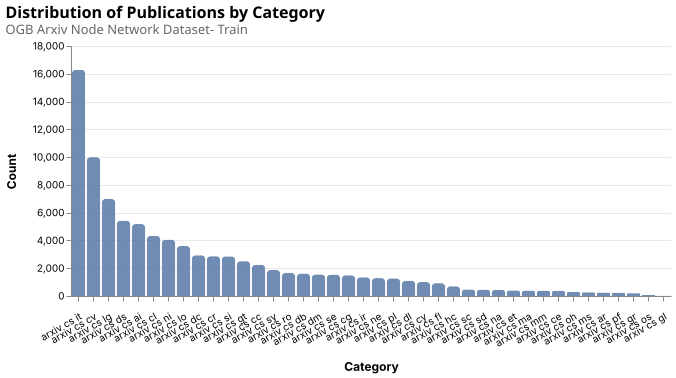

In [27]:
# Plot the distribution of the node labels in the training set
plot_label_distribution(graph.y[graph.train_mask], path_to_graph=graph_params['plots_path'],
                        graph_name=graph_params['name'], label_dict=graph_params['label_dict'],
                        title=graph_params['title'], subtitle=graph_params['subtitle'],
                        split=graph_params['split'],  width=graph_params['width'],
                                  height=graph_params["height"])

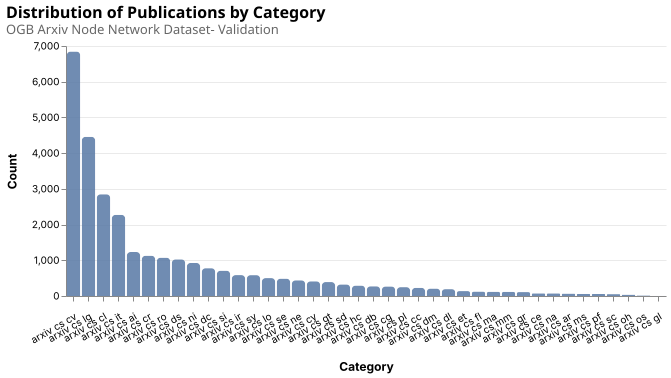

In [28]:
# Plot the distribution of the node labels in the validation set
plot_label_distribution(graph.y[graph.val_mask], path_to_graph=graph_params['plots_path'],
                        graph_name='ogb_val_data_dist', label_dict=graph_params['label_dict'],
                        title=graph_params['title'], subtitle=graph_params['subtitle'],
                        split="Validation", width=graph_params['width'],
                                  height=graph_params["height"])

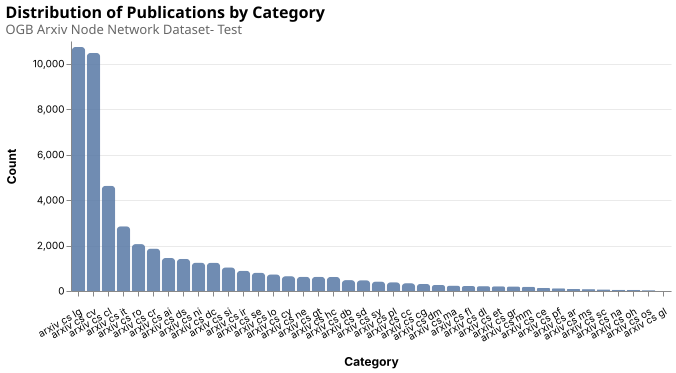

In [29]:
# Plot the distribution of the node labels in the test set
plot_label_distribution(graph.y[graph.test_mask], path_to_graph=graph_params['plots_path'],
                        graph_name='ogb_test_data_dist', label_dict=graph_params['label_dict'],
                        title=graph_params['title'], subtitle=graph_params['subtitle'],
                        split="Test", width=graph_params['width'],
                                  height=graph_params["height"])

<a id="references"></a>
## 8. References

---

[1] Kuansan Wang, Zhihong Shen, Chiyuan Huang, Chieh-Han Wu, Yuxiao Dong, and Anshul Kanakia. Microsoft academic graph: When experts are not enough. Quantitative Science Studies, 1(1):396–413, 2020.

[2] Tomas Mikolov, Ilya Sutskever, Kai Chen, Greg S Corrado, and Jeff Dean. Distributed representations of words and phrases and their compositionality. In Advances in Neural Information Processing Systems (NeurIPS), pp. 3111–3119, 2013.

[3] *Snap Standford - OGB documentation*. [OGB Open Graph Benchmark ](https://ogb.stanford.edu/).

[4] *PyG (PyTorch Geometric) documentation*. [pytorch-geometric.readthedocs.io](https://pytorch-geometric.readthedocs.io/en/latest/index.html#pyg-documentation).
